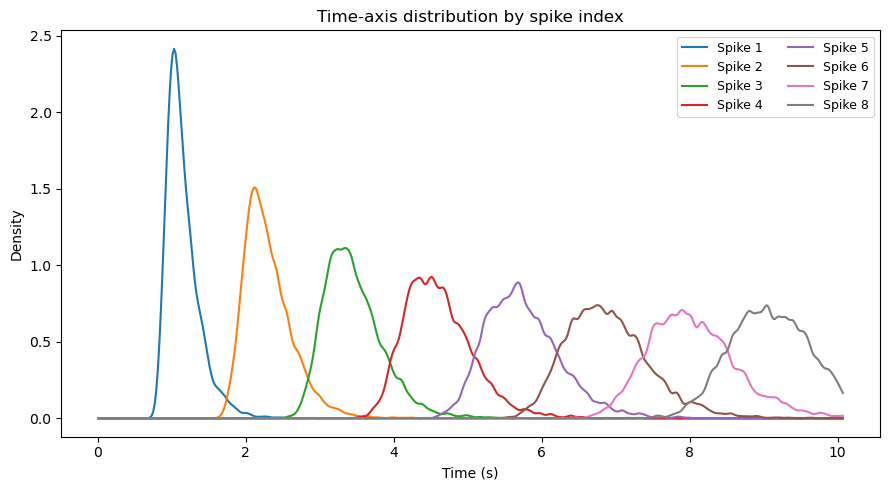

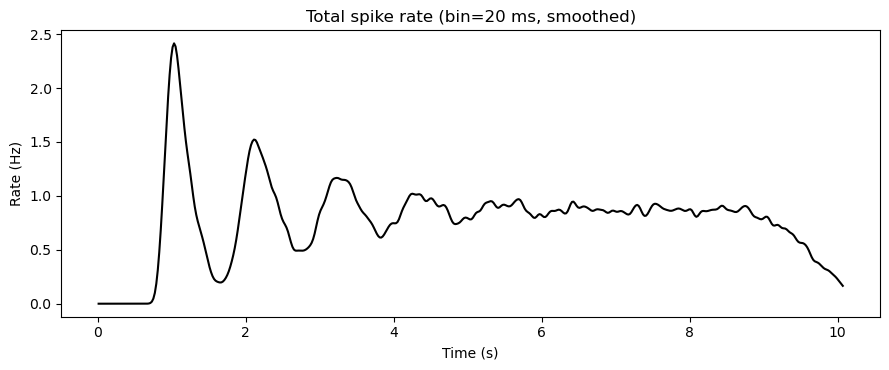

Mean ISI (s): 1.1500786
Std ISI (s): 0.22927524897700705
90th percentile of 8th spike time: 10.0684


In [10]:
# %% [markdown]
# # OU Random Walk with Drift Toward Threshold (Reset after Spike)
# Simulate a random process with drift toward a threshold and noise.
# After each spike, reset to baseline and continue. Visualize spike time distributions.

# %%
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# Random generator for reproducibility
rng = np.random.default_rng(2025)

# ---------------- Parameters (tunable) ----------------
N = 5000           # number of trials
dt = 1e-3          # time step (s)
T_max = 20.0       # total simulated time
x0 = 0.0           # reset value
threshold = 10.0    # spike threshold
k = 5            # drift strength toward threshold (smaller -> slower spikes)
sigma = 0.2        # diffusion amplitude (smaller -> less variability)
max_spikes = 8     # max number of spikes per trial
bin_width = 0.02   # 20 ms histogram bins
smooth_sigma_bins = 2.0  # Gaussian smoothing for visualization
# ------------------------------------------------------

steps = int(T_max / dt)
tgrid = np.linspace(0.0, T_max, steps + 1)

# Initialize state
x = np.full(N, x0)
spike_count = np.zeros(N, dtype=int)
spike_times = np.full((N, max_spikes), np.nan)

# %%
# Simulate the process with Euler–Maruyama and reset after each threshold crossing
for i in range(1, steps + 1):
    alive = spike_count < max_spikes
    if not np.any(alive):
        break

    idx = np.flatnonzero(alive)
    dW = rng.standard_normal(idx.size) * np.sqrt(dt)
    x_alive = x[idx]
    x_alive = x_alive + k * (threshold - x_alive) * dt + sigma * dW
    x[idx] = x_alive

    crossed = x_alive >= threshold
    if np.any(crossed):
        crossed_idx = idx[crossed]
        t_now = tgrid[i]
        sc = spike_count[crossed_idx]
        spike_times[crossed_idx, sc] = t_now
        spike_count[crossed_idx] = sc + 1
        x[crossed_idx] = x0  # reset

# %%
# Compute histogram range (90% of 8th spike)
eighth = spike_times[:, -1]
valid_eighth = eighth[~np.isnan(eighth)]
t_end = np.percentile(valid_eighth, 90) if valid_eighth.size else T_max

# Histogram bins
bins = np.arange(0.0, t_end + bin_width, bin_width)
centers = 0.5 * (bins[:-1] + bins[1:])

# %%
# Spike index–specific distributions
index_densities = []
for i in range(max_spikes):
    ti = spike_times[:, i]
    ti = ti[(~np.isnan(ti)) & (ti <= t_end)]
    c, _ = np.histogram(ti, bins=bins, density=True)
    if smooth_sigma_bins > 0:
        c = gaussian_filter1d(c, smooth_sigma_bins, mode="nearest")
    index_densities.append(c)

# Total spike rate (sum over all spikes)
all_spikes = spike_times.reshape(-1)
all_spikes = all_spikes[(~np.isnan(all_spikes)) & (all_spikes <= t_end)]
counts_total, _ = np.histogram(all_spikes, bins=bins)
rate_total = counts_total / (N * bin_width)  # Hz
if smooth_sigma_bins > 0:
    rate_total = gaussian_filter1d(rate_total, smooth_sigma_bins, mode="nearest")

# %%
# --- Visualization ---

# 1. Per–spike-index distributions
plt.figure(figsize=(9, 5))
for i, c in enumerate(index_densities, start=1):
    plt.plot(centers, c, label=f"Spike {i}")
plt.xlabel("Time (s)")
plt.ylabel("Density")
plt.title("Time-axis distribution by spike index")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# 2. Total spike rate (summed over all spikes)
plt.figure(figsize=(9, 3.8))
plt.plot(centers, rate_total, color="black")
plt.xlabel("Time (s)")
plt.ylabel("Rate (Hz)")
plt.title(f"Total spike rate (bin={int(bin_width*1000)} ms, smoothed)")
plt.tight_layout()
plt.show()

# %%
# Quick summary
isi = np.diff(spike_times, axis=1)
isi = isi[~np.isnan(isi)]
print("Mean ISI (s):", np.mean(isi))
print("Std ISI (s):", np.std(isi))
print("90th percentile of 8th spike time:", np.percentile(valid_eighth, 90) if valid_eighth.size else "N/A")
